This is project Ham vs Spam. The aim is to identify a model that best classifies text as either a ham or a spam.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Load the dataset
ham_spam = pd.read_csv("spam.csv", encoding="latin-1")

# Display the first few rows of the dataset
ham_spam.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


time to explore the date, analyse it, clean it and prepare it for training and testing.

In [2]:
# Explore the dataset
ham_spam.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


In [3]:
ham_spam.describe()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
count,5572,5572,50,12,6
unique,2,5169,43,10,5
top,ham,"Sorry, I'll call later","bt not his girlfrnd... G o o d n i g h t . . .@""","MK17 92H. 450Ppw 16""","GNT:-)"""
freq,4825,30,3,2,2


In [4]:
# Check for missing values
ham_spam.isnull().sum()

v1               0
v2               0
Unnamed: 2    5522
Unnamed: 3    5560
Unnamed: 4    5566
dtype: int64

In [5]:
ham_spam['Unnamed: 2'].value_counts()

Unnamed: 2
 bt not his girlfrnd... G o o d n i g h t . . .@"                                                                                                   3
 PO Box 5249                                                                                                                                        2
this wont even start........ Datz confidence.."                                                                                                     2
GN                                                                                                                                                  2
 don't miss ur best life for anything... Gud nyt..."                                                                                                2
 but dont try to prove it..\" .Gud noon...."                                                                                                        2
 Gud night...."                                                                          

In [6]:
ham_spam['Unnamed: 3'].value_counts()

Unnamed: 3
 MK17 92H. 450Ppw 16"                         2
GE                                            2
 why to miss them                             1
U NO THECD ISV.IMPORTANT TOME 4 2MORO\""      1
i wil tolerat.bcs ur my someone..... But      1
 ILLSPEAK 2 U2MORO WEN IM NOT ASLEEP...\""    1
whoever is the KING\"!... Gud nyt"            1
 TX 4 FONIN HON                               1
 \"OH No! COMPETITION\". Who knew             1
IåÕL CALL U\""                                1
Name: count, dtype: int64

In [7]:
ham_spam['Unnamed: 4'].value_counts()

Unnamed: 4
GNT:-)"                                                     2
 just Keep-in-touch\" gdeve.."                              1
 Never comfort me with a lie\" gud ni8 and sweet dreams"    1
 CALL 2MWEN IM BK FRMCLOUD 9! J X\""                        1
 one day these two will become FREINDS FOREVER!"            1
Name: count, dtype: int64

The Unnamed texts clearly have a purpose, but we need to identify that and rename them to provide clarity.

In [8]:
# Checking  for the contexts of Unnamed: 2, 3, and 4
#Checking for instances where Unnamed: 2 is not null
ham_spam[ham_spam['Unnamed: 2'].notnull()]

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
95,spam,Your free ringtone is waiting to be collected....,PO Box 5249,"MK17 92H. 450Ppw 16""",NaN
281,ham,\Wen u miss someone,the person is definitely special for u..... B...,why to miss them,"just Keep-in-touch\"" gdeve.."""
444,ham,\HEY HEY WERETHE MONKEESPEOPLE SAY WE MONKEYAR...,HOWU DOIN? FOUNDURSELF A JOBYET SAUSAGE?LOVE ...,NaN,NaN
671,spam,SMS. ac sun0819 posts HELLO:\You seem cool,"wanted to say hi. HI!!!\"" Stop? Send STOP to ...",NaN,NaN
710,ham,Height of Confidence: All the Aeronautics prof...,"this wont even start........ Datz confidence..""",NaN,NaN
899,spam,Your free ringtone is waiting to be collected....,PO Box 5249,"MK17 92H. 450Ppw 16""",NaN
1038,ham,"Edison has rightly said, \A fool can ask more ...",GN,GE,"GNT:-)"""
1127,ham,"Height of \Oh shit....!!\"" situation: A guy th...",".;-):-D""",NaN,NaN
1266,ham,\Hey sorry I didntgive ya a a bellearlier hunny,just been in bedbut mite go 2 thepub l8tr if u...,NaN,NaN
1384,ham,"Storming msg: Wen u lift d phne, u say \HELLO\...","bt not his girlfrnd... G o o d n i g h t . . .@""",NaN,NaN


In [9]:
#Checking for instances where Unnamed: 3 is not null
ham_spam[ham_spam['Unnamed: 3'].notnull()]

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
95,spam,Your free ringtone is waiting to be collected....,PO Box 5249,"MK17 92H. 450Ppw 16""",NaN
281,ham,\Wen u miss someone,the person is definitely special for u..... B...,why to miss them,"just Keep-in-touch\"" gdeve.."""
899,spam,Your free ringtone is waiting to be collected....,PO Box 5249,"MK17 92H. 450Ppw 16""",NaN
1038,ham,"Edison has rightly said, \A fool can ask more ...",GN,GE,"GNT:-)"""
2170,ham,\CAN I PLEASE COME UP NOW IMIN TOWN.DONTMATTER...,JUST REALLYNEED 2DOCD.PLEASE DONTPLEASE DONTIG...,"U NO THECD ISV.IMPORTANT TOME 4 2MORO\""""",NaN
2255,ham,I just lov this line: \Hurt me with the truth,I don't mind,i wil tolerat.bcs ur my someone..... But,"Never comfort me with a lie\"" gud ni8 and swe..."
3145,ham,\SHIT BABE.. THASA BIT MESSED UP.YEH,SHE SHUDVETOLD U. DID URGRAN KNOW?NEWAY,"ILLSPEAK 2 U2MORO WEN IM NOT ASLEEP...\""""",NaN
3506,ham,Two fundamentals of cool life: \Walk,"like you are the KING\""...! OR \""Walk like yo...","whoever is the KING\""!... Gud nyt""",NaN
3525,ham,\HEY BABE! FAR 2 SPUN-OUT 2 SPK AT DA MO... DE...,HAD A COOL NYTHO,TX 4 FONIN HON,"CALL 2MWEN IM BK FRMCLOUD 9! J X\"""""
4668,ham,"When I was born, GOD said, \Oh No! Another IDI...",GOD said,"\""OH No! COMPETITION\"". Who knew","one day these two will become FREINDS FOREVER!"""


In [10]:
# Checking for instances where Unnamed: 4 is not null
ham_spam[ham_spam['Unnamed: 4'].notnull()]

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
281,ham,\Wen u miss someone,the person is definitely special for u..... B...,why to miss them,"just Keep-in-touch\"" gdeve.."""
1038,ham,"Edison has rightly said, \A fool can ask more ...",GN,GE,"GNT:-)"""
2255,ham,I just lov this line: \Hurt me with the truth,I don't mind,i wil tolerat.bcs ur my someone..... But,"Never comfort me with a lie\"" gud ni8 and swe..."
3525,ham,\HEY BABE! FAR 2 SPUN-OUT 2 SPK AT DA MO... DE...,HAD A COOL NYTHO,TX 4 FONIN HON,"CALL 2MWEN IM BK FRMCLOUD 9! J X\"""""
4668,ham,"When I was born, GOD said, \Oh No! Another IDI...",GOD said,"\""OH No! COMPETITION\"". Who knew","one day these two will become FREINDS FOREVER!"""
5048,ham,"Edison has rightly said, \A fool can ask more ...",GN,GE,"GNT:-)"""


It seems like the Unnamed columns do not have any order persay, but are just a continuation of the text message in v2. And since v2 seems to capture the main message we are looking at and the Unnamed columns contain too many missing values anyway, I think we might as well drop them. 

In [11]:
# Checking the correlation between v1 being ham or spam and the columns Unnamed: 2, 3, and 4

#ham_spam[ham_spam['v1'] == 'spam'].corr(ham_spam['Unnamed: 2'].notnull())

# Could not compute correlation due to the nature of the data in Unnamed: 2, 3, and 4. Instead, we can check the distribution of ham and spam messages in relation to the presence of values in these columns.
# Create a new column to indicate the presence of values in Unnamed: 2, 3, and 4
ham_spam['Unnamed: 2_present'] = ham_spam['Unnamed: 2'].notnull()
ham_spam['Unnamed: 3_present'] = ham_spam['Unnamed: 3'].notnull()
ham_spam['Unnamed: 4_present'] = ham_spam['Unnamed: 4'].notnull()
# Check the distribution of ham and spam messages in relation to the presence of values in Unnamed: 2, 3, and 4
print(ham_spam.groupby(['v1', 'Unnamed: 2_present']).size())
print(ham_spam.groupby(['v1', 'Unnamed: 3_present']).size())
print(ham_spam.groupby(['v1', 'Unnamed: 4_present']).size())

v1    Unnamed: 2_present
ham   False                 4780
      True                    45
spam  False                  742
      True                     5
dtype: int64
v1    Unnamed: 3_present
ham   False                 4815
      True                    10
spam  False                  745
      True                     2
dtype: int64
v1    Unnamed: 4_present
ham   False                 4819
      True                     6
spam  False                  747
dtype: int64


From my observation, both ham and spam feature in Unnamed: 2 and 3, and only ham features in Unnamed: 4. And the frequency of ham is more in all the instances compared to spam. Interesting. It seems the longer a message is, the more likely it is not a spam. I wonder if the same holds true in the messages in v2.

In [12]:
# Checking the correlation between v1 being ham or spam and the length of the message in v2
# Creating a new column for the length of the message in v2
ham_spam['message_length'] = ham_spam['v2'].apply(len)

# Calculating the correlation between v1 being ham or spam and the length of the message in v2
correlation = ham_spam['v1'].apply(lambda x: 1 if x == 'spam' else 0).corr(ham_spam['message_length'])

# Displaying the correlation
print(f"Correlation between v1 being ham or spam and the length of the message in v2: {correlation}")

Correlation between v1 being ham or spam and the length of the message in v2: 0.3872852892684756


The correlation is not so high, so, it's probably not a feature to consider for the Unnamed columns. Time to drop the columns, plus the new ones.

In [13]:
ham_spam.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 2_present,Unnamed: 3_present,Unnamed: 4_present,message_length
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN,False,False,False,111
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN,False,False,False,29
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN,False,False,False,155
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN,False,False,False,49
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN,False,False,False,61


In [14]:
# Drop the unnecessary columns. Maybe we can keep the message_length column for further analysis.
ham_spam_df = ham_spam.drop(columns=['Unnamed: 2',
                                    'Unnamed: 3', ''
                                    'Unnamed: 4', 
                                    'Unnamed: 2_present', 
                                    'Unnamed: 3_present', 
                                    'Unnamed: 4_present', 
                                    #'message_length'
                                    ])

ham_spam_df.head()

,v1,v2,message_length
0,ham,"Go until jurong point, crazy.. Available only ...",111
1,ham,Ok lar... Joking wif u oni...,29
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,ham,U dun say so early hor... U c already then say...,49
4,ham,"Nah I don't think he goes to usf, he lives aro...",61


In [15]:
# Renaming the columns for better readability
ham_spam_df = ham_spam_df.rename(columns={'v1': 'label', 
                                          'v2': 'message'
                                        
                                          })
ham_spam_df.head()

,label,message,message_length
0,ham,"Go until jurong point, crazy.. Available only ...",111
1,ham,Ok lar... Joking wif u oni...,29
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,ham,U dun say so early hor... U c already then say...,49
4,ham,"Nah I don't think he goes to usf, he lives aro...",61


In [16]:
# Creating a new column  for spam = 1 and ham = 0
#ham_spam_df['spam'] = ham_spam_df['label'].apply(lambda x: 1 if x == 'spam' else 0)
#ham_spam_df.head()

In [17]:
# Converting the message column to lowercase for better text processing
ham_spam_df['message'] = ham_spam_df['message'].str.lower()
ham_spam_df.head()

,label,message,message_length
0,ham,"go until jurong point, crazy.. available only ...",111
1,ham,ok lar... joking wif u oni...,29
2,spam,free entry in 2 a wkly comp to win fa cup fina...,155
3,ham,u dun say so early hor... u c already then say...,49
4,ham,"nah i don't think he goes to usf, he lives aro...",61


In [18]:
ham_spam_dummy = pd.get_dummies(ham_spam_df['label'], drop_first=True, dtype=int)
ham_spam_df = pd.concat([ham_spam_df, ham_spam_dummy], axis=1)
ham_spam_dummy.head()

,spam
0,0
1,0
2,1
3,0
4,0


In [19]:
ham_spam_df.head()

,label,message,message_length,spam
0,ham,"go until jurong point, crazy.. available only ...",111,0
1,ham,ok lar... joking wif u oni...,29,0
2,spam,free entry in 2 a wkly comp to win fa cup fina...,155,1
3,ham,u dun say so early hor... u c already then say...,49,0
4,ham,"nah i don't think he goes to usf, he lives aro...",61,0


This code below will randomly sample hams as the majority class and combine it with spam to create a balanced sample where the numbers of hams and spams are equal. Might see what a balanced dataset will produce, maybe capturing an instance where the probability of ham/spam is 50/50. 

In [20]:
# Class balancing using undersampling
# Separate the majority and minority classes
#ham = ham_spam_df[ham_spam_df['spam'] == 0]
#spam = ham_spam_df[ham_spam_df['spam'] == 1]
# Undersample the majority class (ham)
#ham_undersampled = ham.sample(len(spam), random_state=42)
# Combine the undersampled majority class with the minority class
#ham_spam_balanced = pd.concat([ham_undersampled, spam])
# Shuffle the dataset
#ham_spam_balanced = ham_spam_balanced.sample(frac=1, random_state=42).reset_index(drop=True)
#ham_spam_balanced.head(10)

In [21]:
#ham_spam_balanced.describe()

In [22]:
#display only where label is spam
#ham_spam_balanced[ham_spam_balanced['label'] == 'spam'].head(20)

In [23]:
# CHeck the correlation between spam and the length of the message
correlation = ham_spam_df['spam'].corr(ham_spam_df['message_length'])
print(f"Correlation between spam and the length of the message in the balanced dataset: {correlation}")

Correlation between spam and the length of the message in the balanced dataset: 0.3872852892684756


In [24]:
# Train test split
from sklearn.model_selection import train_test_split

text = ham_spam_df['message']
labels = ham_spam_df['spam']

X_train, X_test, y_train, y_test = train_test_split(text, labels, test_size=0.25, random_state=42, stratify = labels)


In [25]:
# Converting the message column to vectorized form using TF-IDF Vectorizer
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vectorizer = TfidfVectorizer()
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)



In [26]:
# baseline model using Decision Tree Classifier
from sklearn.tree import DecisionTreeClassifier, plot_tree

dt = DecisionTreeClassifier(random_state=42, max_depth=19)
dt.fit(X_train_tfidf, y_train)

dt_predictions = dt.predict(X_test_tfidf)


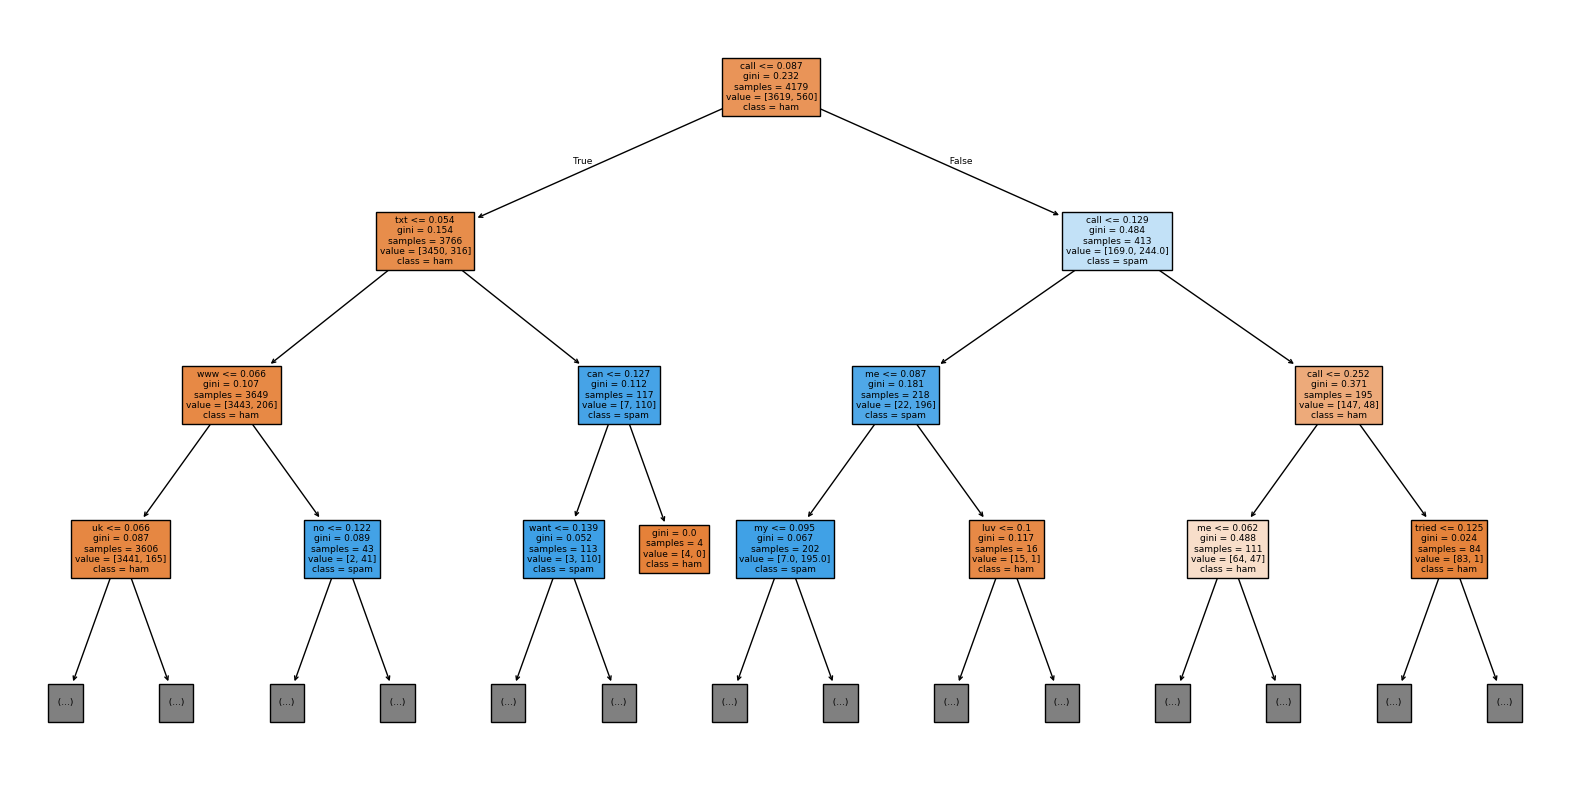

In [27]:
# Plotting the decision tree
plt.figure(figsize=(20,10))
plot_tree(dt, filled=True, feature_names=tfidf_vectorizer.get_feature_names_out(), class_names=['ham', 'spam'], max_depth=3)
plt.show()

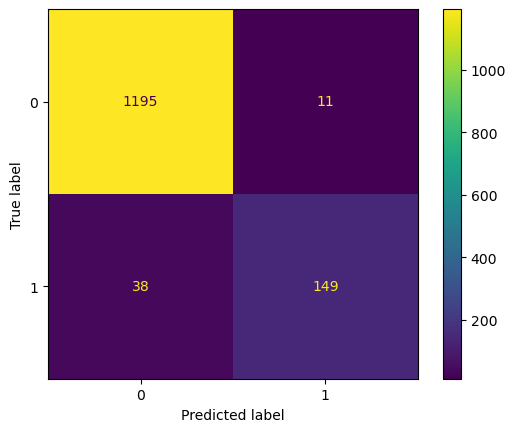

In [28]:


# Evaluating the model using classification report and confusion matrix
from sklearn.metrics import ConfusionMatrixDisplay, classification_report, confusion_matrix

cm = confusion_matrix(y_test, dt_predictions)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=dt.classes_)
disp.plot()
plt.show()

In [29]:
# Evaluating the model
print("Classification Report:")
from sklearn.metrics import classification_report
print(classification_report(y_test, dt_predictions))


Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.99      0.98      1206
           1       0.93      0.80      0.86       187

    accuracy                           0.96      1393
   macro avg       0.95      0.89      0.92      1393
weighted avg       0.96      0.96      0.96      1393



In [30]:
# Checking the different depth values for the decision tree and their impact on the model's performance
for depth in range(1, 25, 2):
    dt = DecisionTreeClassifier(random_state=42, max_depth=depth)
    dt.fit(X_train_tfidf, y_train)
    dt_predictions = dt.predict(X_test_tfidf)
    print(f"Depth: {depth}")
    print(classification_report(y_test, dt_predictions))

Depth: 1
              precision    recall  f1-score   support

           0       0.92      0.97      0.94      1206
           1       0.67      0.45      0.54       187

    accuracy                           0.90      1393
   macro avg       0.79      0.71      0.74      1393
weighted avg       0.88      0.90      0.89      1393

Depth: 3
              precision    recall  f1-score   support

           0       0.93      1.00      0.96      1206
           1       0.94      0.51      0.66       187

    accuracy                           0.93      1393
   macro avg       0.94      0.75      0.81      1393
weighted avg       0.93      0.93      0.92      1393

Depth: 5
              precision    recall  f1-score   support

           0       0.95      0.99      0.97      1206
           1       0.89      0.65      0.75       187

    accuracy                           0.94      1393
   macro avg       0.92      0.82      0.86      1393
weighted avg       0.94      0.94      0.94    

A depth level of 19 seems to be the best level for peek performance. With an accuracy score of 96%, and the highest recal score of 80%.

In [31]:
# Plotting an ROC curve for the model
from sklearn.metrics import roc_curve, auc
y_prob = dt.predict_proba(X_test_tfidf)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_prob)



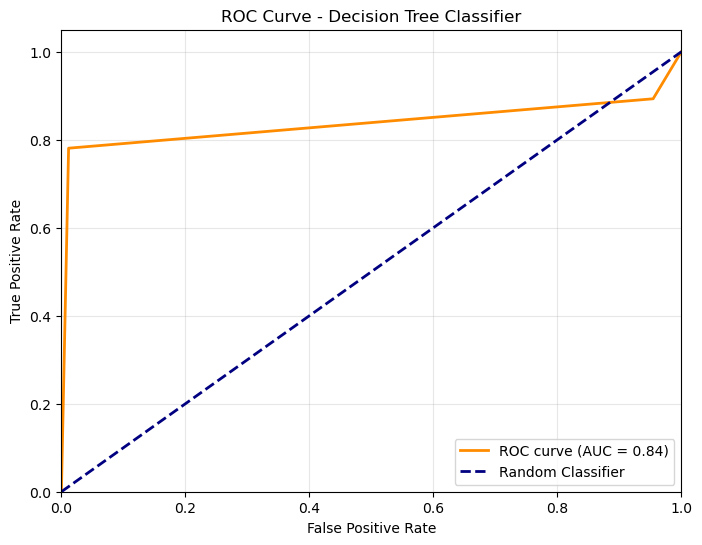

In [32]:
import matplotlib.pyplot as plt

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Decision Tree Classifier')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

Trying out a Logistic Regression model to see if its recall performance will be any better.

In [33]:
# A Logistic Regression model
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(random_state=42)
lr.fit(X_train_tfidf, y_train)



,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


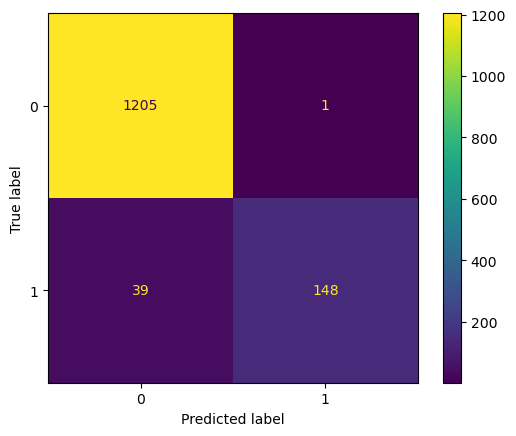

In [34]:
# Evaluating the Logistic Regression model as a baseline model

lr_predictions = lr.predict(X_test_tfidf)

cm_2 = confusion_matrix(y_test, lr_predictions)
disp_lr = ConfusionMatrixDisplay(confusion_matrix=cm_2, display_labels=dt.classes_)
disp_lr.plot()
plt.show()

In [35]:
# Classification Report

print("Classification Report:")
from sklearn.metrics import classification_report
print(classification_report(y_test, lr_predictions))

Classification Report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.98      1206
           1       0.99      0.79      0.88       187

    accuracy                           0.97      1393
   macro avg       0.98      0.90      0.93      1393
weighted avg       0.97      0.97      0.97      1393



In [36]:
# gridsearch for the best Logistic regression model

from sklearn.model_selection import GridSearchCV

# Defining the parameter grid for LogisticRegression
param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'solver': ['liblinear', 'lbfgs', 'saga'],
    'penalty': ['l1', 'l2'],
}

# Instantiate GridSearchCV
grid_search = GridSearchCV(lr, param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=2)

# Fit GridSearchCV to the scaled training data
grid_search.fit(X_train_tfidf, y_train)

Fitting 5 folds for each of 36 candidates, totalling 180 fits


c:\Users\chept\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py:516: FitFailedWarning: 
30 fits failed out of a total of 180.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
30 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\chept\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\chept\anaconda3\Lib\site-packages\sklearn\base.py", line 1365, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "c:\Users\chept\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py", line 1218, in fit
    solver = 

,estimator,LogisticRegre...ndom_state=42)
,param_grid,"{'C': [0.001, 0.01, ...], 'penalty': ['l1', 'l2'], 'solver': ['liblinear', 'lbfgs', ...]}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,5
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,penalty,'l1'


In [37]:
# Print the best parameters and best score
print("Best parameters: ", grid_search.best_params_)
print("Best cross-validation score: ", grid_search.best_score_)

# Get the best model
best_lr_model = grid_search.best_estimator_

# Evaluate the best model
test_score = best_lr_model.score(X_test_tfidf, y_test)
print(f"Test set accuracy with best model: {test_score}")

Best parameters:  {'C': 100, 'penalty': 'l1', 'solver': 'saga'}
Best cross-validation score:  0.9820542646763888
Test set accuracy with best model: 0.9870782483847811


In [38]:
# Checking the classification report for the best model
print("Classification Report for Best Logistic Regression Model:")
print(classification_report(y_test, best_lr_model.predict(X_test_tfidf)))

Classification Report for Best Logistic Regression Model:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1206
           1       0.99      0.91      0.95       187

    accuracy                           0.99      1393
   macro avg       0.99      0.96      0.97      1393
weighted avg       0.99      0.99      0.99      1393



In [39]:
best_lr_model_pred = best_lr_model.predict(X_test_tfidf)

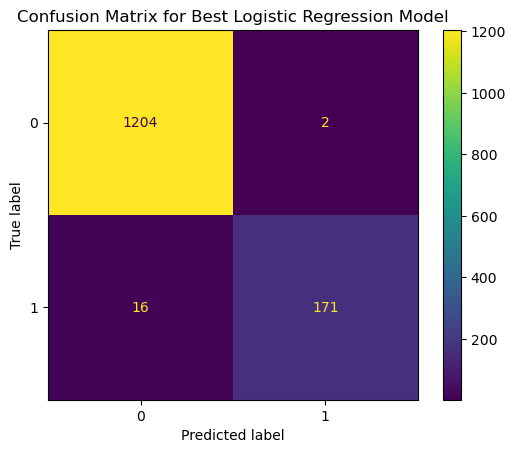

In [40]:
# Plot the confusion matrix for the best model
cm_best = confusion_matrix(y_test, best_lr_model.predict(X_test_tfidf))
disp_best = ConfusionMatrixDisplay(confusion_matrix=cm_best)
disp_best.plot()
plt.title("Confusion Matrix for Best Logistic Regression Model")
plt.show()

In [41]:
# Plotting an ROC curve for the model
from sklearn.metrics import roc_curve, auc
y_proba = best_lr_model.predict_proba(X_test_tfidf)[:, 1]
fpr_blr, tpr_blr, thresholds_blr = roc_curve(y_test, y_proba)



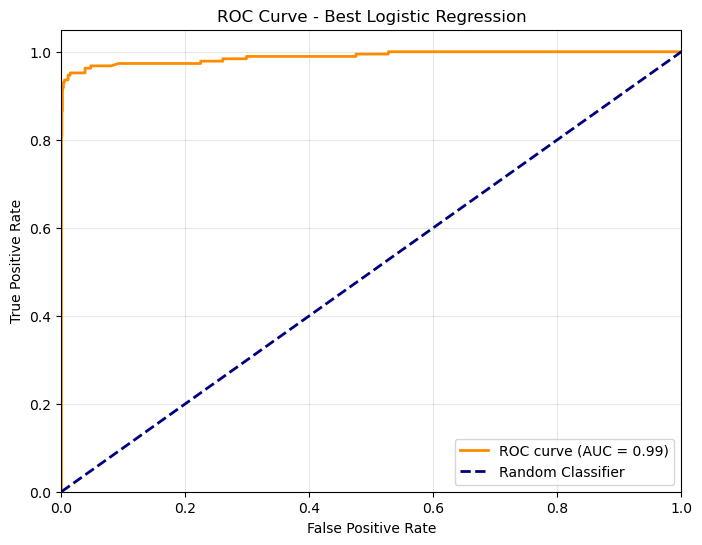

In [42]:
roc_auc_blr = auc(fpr_blr, tpr_blr)

plt.figure(figsize=(8, 6))
plt.plot(fpr_blr, tpr_blr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc_blr:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Best Logistic Regression')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

In [43]:
# comparing the performances of the models

# --- IGNORE ---
#for depth in range(1, 25, 2):
    #dt = DecisionTreeClassifier(random_state=42, max_depth=depth)
    #dt.fit(X_train_tfidf, y_train)
    #dt_predictions = dt.predict(X_test_tfidf)
    #print(f"Depth: {depth}")
    #print(classification_report(y_test, dt_predictions))
#model = ['DecisionTreeClassifier',
 #        'LogisticRegression',
  #       'best_lr_model']

#for model_prediction in (dt_predictions, lr_predictions, best_lr_model_pred):

  #  for model in ('DecisionTreeClassifier(dt)', 'LogisticRegression(lr)', 'Best_LogisticRegression' ):
   #     print(f"Classification Report for {model}:")
    #print(classification_report(y_test, model_prediction))

models = {'DecisionTreeClassifier':dt, 'Logistic Regression(Initial)': lr, 'Logistic Regression (Best GridSearchCV)': best_lr_model}

for name, model in models.items():
    print(f"\n--- Classification Report for {name} ---")
    print(classification_report(y_test, model.predict(X_test_tfidf)))



--- Classification Report for DecisionTreeClassifier ---
              precision    recall  f1-score   support

           0       0.97      0.99      0.98      1206
           1       0.91      0.78      0.84       187

    accuracy                           0.96      1393
   macro avg       0.94      0.88      0.91      1393
weighted avg       0.96      0.96      0.96      1393


--- Classification Report for Logistic Regression(Initial) ---
              precision    recall  f1-score   support

           0       0.97      1.00      0.98      1206
           1       0.99      0.79      0.88       187

    accuracy                           0.97      1393
   macro avg       0.98      0.90      0.93      1393
weighted avg       0.97      0.97      0.97      1393


--- Classification Report for Logistic Regression (Best GridSearchCV) ---
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1206
           1       0.99      0.91      0

Conclusion

The 'Best Logistic Regression Model' has the best performance for all the models in this analysis. With a Recall value of 91% on the test sample, F1 score of 95%, a Precision of 99% and a 99% accuracy. These are the highest scores for any model in this analysis. The ROC curve also shows its high performance with the True Positive Rate peeking high at 1, to a False Positive Rate of around 0.5, and an AUC of 0.99.

With precision being the rate of predicting spams(99%), and recall the rate at which actual spams were identified correctly(91%), the model still has a high false negative value, which could lead to a number of spams slipping through the spam filter.

To improve the spam filter, I would recommend using ensemble methods such as Random Forest and tuning the hyperparameters for the best result. I did not use N_grams because I figured that, with the texts having a lot of rare phrases such as short forms and typos, the vectorizer would not generalize well. But trying it out to see how it handles the phrases anyway. It could improve the performance.


In [44]:
# -------------------- IGNORE!!! RANDOM MUSINGS!!! --------------------------


# Using a Random Forest model
from sklearn.ensemble import RandomForestClassifier

# Making an instance of the model
rf = RandomForestClassifier()

#fitting the model on the vectorized training data
rf.fit(X_train_tfidf, y_train)


,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [45]:
# Classification Report for Random Forest Classifier

print("Classification Report for Random Forest Classifier:")
print(classification_report(y_test, rf.predict(X_test_tfidf)))


Classification Report for Random Forest Classifier:
              precision    recall  f1-score   support

           0       0.97      1.00      0.98      1206
           1       1.00      0.77      0.87       187

    accuracy                           0.97      1393
   macro avg       0.98      0.89      0.93      1393
weighted avg       0.97      0.97      0.97      1393



In [46]:
# Tuning the RandomForest hyperparameters
# Defining the pa
param_grid_rf={    
    'n_estimators': [100, 200, 500],
    'max_depth': [10, 20, 2]
}

# Instantiate GridSearchCV
grid_search_rf = GridSearchCV(rf, param_grid_rf, cv=5, scoring='accuracy', n_jobs=-1, verbose=2)

# Fit GridSearchCV to the scaled training data
grid_search_rf.fit(X_train_tfidf, y_train)

Fitting 5 folds for each of 9 candidates, totalling 45 fits


,estimator,RandomForestClassifier()
,param_grid,"{'max_depth': [10, 20, ...], 'n_estimators': [100, 200, ...]}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,5
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,200


In [47]:
# Print the best parameters and best score
print("Best parameters: ", grid_search_rf.best_params_)
print("Best cross-validation score: ", grid_search_rf.best_score_)

# Get the best model
best_rf_model = grid_search_rf.best_estimator_

# Evaluate the best model
test_score_rf = best_rf_model.score(X_test_tfidf, y_test)
print(f"Test set accuracy with best model: {test_score_rf}")

Best parameters:  {'max_depth': 20, 'n_estimators': 200}
Best cross-validation score:  0.9535796349883965
Test set accuracy with best model: 0.9483129935391242


In [48]:
# Classification report for Best_rf 

print("Classification Report for Best Random Forest Classifier:")
print(classification_report(y_test, best_rf_model.predict(X_test_tfidf)))


Classification Report for Best Random Forest Classifier:
              precision    recall  f1-score   support

           0       0.94      1.00      0.97      1206
           1       1.00      0.61      0.76       187

    accuracy                           0.95      1393
   macro avg       0.97      0.81      0.87      1393
weighted avg       0.95      0.95      0.94      1393



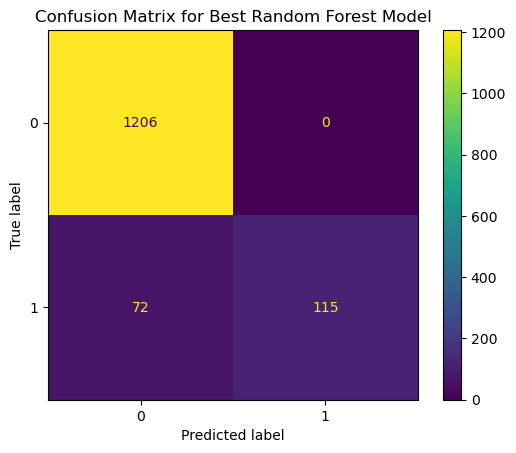

In [50]:
# Plot the confusion matrix for the best RF model
cm_best_rf = confusion_matrix(y_test, best_rf_model.predict(X_test_tfidf))
disp_best_rf = ConfusionMatrixDisplay(confusion_matrix=cm_best_rf)
disp_best_rf.plot()
plt.title("Confusion Matrix for Best Random Forest Model")
plt.show()

There is a 100% result in precision for filtering spams, but the performance in recall is terrible. Would only be useful when putting a higher consideration for false positives- no hams would get misidentified as spams by the model, but a good number of spams would be misidentified as hams, defeating its purpose as a spam filter. 

This may be improved by a different vectorizer, maybe N_grams. Or, there might be a hyperparameter that may better the result.

In [51]:
# --- IGNORE ---

# Using an embedding model to plot a graph of the texts and their labels
#from sentence_transformers import SentenceTransformer

#loading a Hugging Face embedding model
#embedder = SentenceTransformer('BAAI/bge-base-en-v1.5')

#threw an error 'ModuleNotFoundError' though I had pip installed sentence_transformers. will work on this.